/var/folders/38/sshrd9n5547dsv7xj9ft04n00000gn/T/ipykernel_4481/1244258893.py:16: RuntimeWarning: invalid value encountered in scalar divide
  pi_estimate = 4 * points_inside / num_samples


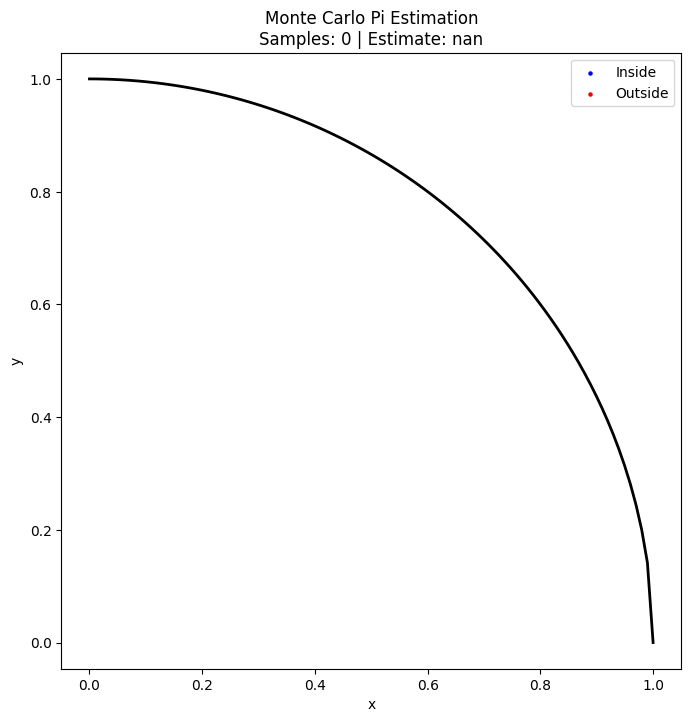

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_pi(num_samples):
    # Generate random x and y coordinates between 0 and 1
    x = np.random.rand(num_samples)
    y = np.random.rand(num_samples)
    
    # Calculate distance from origin (0,0)
    # Point is inside if x^2 + y^2 <= 1
    distances = x**2 + y**2
    inside_circle = distances <= 1
    
    # Estimate Pi
    points_inside = np.sum(inside_circle)
    pi_estimate = 4 * points_inside / num_samples
    
    # Visualization
    plt.figure(figsize=(8, 8))
    
    # Plot points inside in blue, outside in red
    plt.scatter(x[inside_circle], y[inside_circle], color='blue', s=5, label='Inside')
    plt.scatter(x[~inside_circle], y[~inside_circle], color='red', s=5, label='Outside')
    
    # Draw the quarter-circle arc for reference
    cx = np.linspace(0, 1, 100)
    cy = np.sqrt(1 - cx**2)
    plt.plot(cx, cy, color='black', linewidth=2)
    
    plt.title(f"Monte Carlo Pi Estimation\nSamples: {num_samples} | Estimate: {pi_estimate:.5f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.show()

# Try varying this number to see the convergence!
estimate_pi(0)

In [38]:
def estimate_pi2(num_samples):
    # Generate random x and y coordinates between 0 and 1
    x = np.random.rand(num_samples)
    y = np.random.rand(num_samples)
    
    # Calculate distance from origin (0,0)
    # Point is inside if x^2 + y^2 <= 1
    distances = x**2 + y**2
    inside_circle = distances <= 1
    
    # Estimate Pi
    points_inside = np.sum(inside_circle)
    pi_estimate = 4 * points_inside / num_samples

    return pi_estimate

array_samples = [10, 100, 1000, 10000, 100000, 1000000, 10**7]
n_reps = 10000

outcome = np.zeros((n_reps, len(array_samples)))

for k in range(len(array_samples)):
    num_samples = array_samples[k]
    for i in range(n_reps):
        outcome[i, k] = estimate_pi2(num_samples)

means = np.mean(outcome, axis = 0)
variances = np.var(outcome, axis = 0)

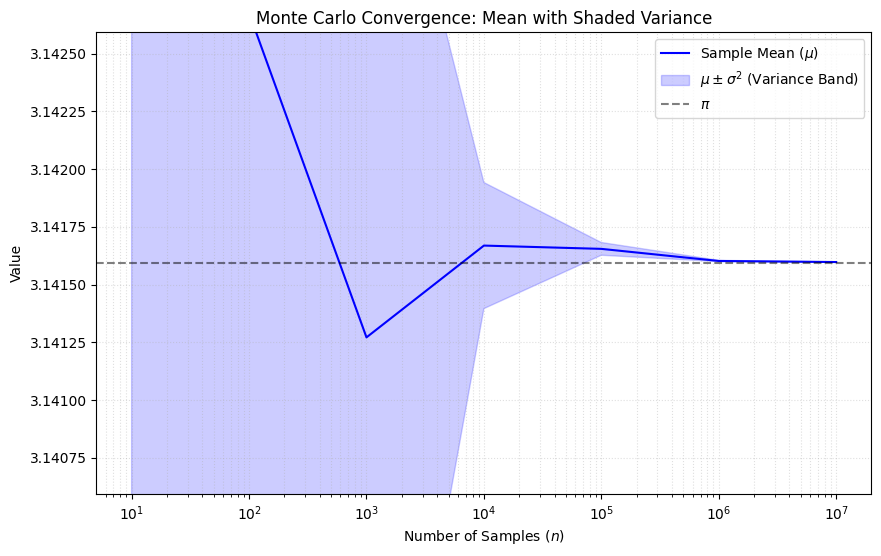

In [ ]:
# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the Mean as a solid line
plt.plot(array_samples, means, color='blue', label=r'Sample Mean ($\mu$)', linewidth=1.5)

# Plot the Variance as a shaded area around the mean
# We fill the area between (mean - variance) and (mean + variance)
plt.fill_between(array_samples, means - variances, means + variances, 
                 color='blue', alpha=0.2, label=r'$\mu \pm \sigma^2$ (Variance Band)')

# Add theoretical reference line for the mean
plt.axhline(np.pi, color='black', linestyle='--', alpha=0.5, label=r'$\pi$')

plt.ylim((np.pi-1e-3, np.pi+1e-3))

# Formatting
plt.xscale('log')
plt.xlabel('Number of Samples ($n$)')
plt.ylabel('Value')
#plt.title('Monte Carlo Convergence: Mean with Shaded Variance')
plt.legend(loc='upper right')
plt.grid(True, which="both", linestyle=':', alpha=0.4)

# Lunar lander

In [37]:
import gymnasium as gym

def mc_prediction_lunar_lander(n_episodes=500):
    env = gym.make("LunarLander-v3")
    
    returns = []
    running_means = []
    
    print(f"Starting Monte Carlo estimation for {n_episodes} episodes...")

    for i in range(1, n_episodes + 1):
        state, info = env.reset()
        done = False
        truncated = False
        episode_return = 0
        
        # Policy: Simple heuristic (you can replace this with a trained policy)
        # Here, we use a random policy to demonstrate the 'Baseline' value
        while not (done or truncated):
            action = env.action_space.sample() 
            state, reward, done, truncated, info = env.step(action)
            episode_return += reward
            
        returns.append(episode_return)
        running_means.append(np.mean(returns))
        
        if i % 100 == 0:
            print(f"Episode {i}/{n_episodes} - Average Return: {running_means[-1]:.2f}")

    env.close()
    return running_means, np.var(returns)

# Run the simulation
n_episodes = 1000
means, variance = mc_prediction_lunar_lander(n_episodes)

# Visualization
plt.figure(figsize=(10, 6))
episodes = np.arange(1, n_episodes + 1)

# Plot Mean Return (Estimation of V(s_start))
plt.plot(episodes, means, color='blue', label=r'Estimated Value $V(s_{start})$')

# Shaded Variance (using the logic from our previous plots)
# We use a constant final variance to show the spread of the environment
plt.fill_between(episodes, means - np.sqrt(variance), means + np.sqrt(variance), 
                 color='blue', alpha=0.1, label='Standard Deviation Band')

plt.xscale('log')
plt.ylim(-600, 200) # Typical reward range for Lunar Lander
plt.xlabel(r'Number of Episodes ($n$)')
plt.ylabel('Total Reward (Return $G$)')
plt.title('MC Prediction: Estimating Value of Initial State (Lunar Lander)')
plt.legend()
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.show()

DependencyNotInstalled: Box2D is not installed, you can install it by run `pip install swig` followed by `pip install "gymnasium[box2d]"`